In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

face = cv2.imread("C:\\Users\\admin\\Downloads\\my photo.jpg")
glass = cv2.imread("C:\\Users\\admin\\Downloads\\sunglass.png")

In [30]:
gray = cv2.cvtColor(glass, cv2.COLOR_BGR2GRAY)

In [31]:
_, mask = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)

SANTHOSH KUMAR A
212224230250


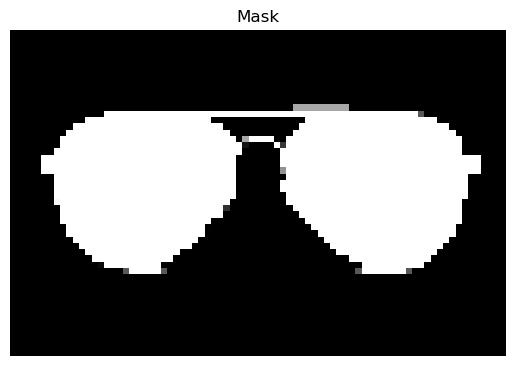

In [42]:
plt.imshow(mask, cmap='gray')
print("SANTHOSH KUMAR A")
print("212224230250")
plt.title("Mask")
plt.axis("off")
plt.show()

In [33]:
eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye_tree_eyeglasses.xml"
)

gray_face = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
eyes = eye_cascade.detectMultiScale(gray_face, 1.1, 10)

In [34]:
eyes = sorted(eyes, key=lambda e:e[2]*e[3], reverse=True)[:2]
eyes = sorted(eyes, key=lambda e:e[0])

left_eye = (
    eyes[0][0] + eyes[0][2]//2,
    eyes[0][1] + eyes[0][3]//2
)

right_eye = (
    eyes[1][0] + eyes[1][2]//2,
    eyes[1][1] + eyes[1][3]//2
)

In [35]:
eye_distance = np.linalg.norm(
    np.array(right_eye) - np.array(left_eye)
)

glass_width = int(eye_distance * 2.2)

glass_height = int(
    glass.shape[0] * glass_width / glass.shape[1]
)

glass = cv2.resize(glass, (glass_width, glass_height))
mask = cv2.resize(mask, (glass_width, glass_height))

In [36]:
x = int((left_eye[0] + right_eye[0])/2 - glass_width/2)
y = int(min(left_eye[1], right_eye[1]) - glass_height/3)

In [37]:
roi = face[y:y+glass_height, x:x+glass_width]

In [38]:
mask_inv = cv2.bitwise_not(mask)

face_bg = cv2.bitwise_and(
    roi,
    roi,
    mask=mask_inv
)

glass_fg = cv2.bitwise_and(
    glass,
    glass,
    mask=mask
)

In [39]:
dst = cv2.add(face_bg, glass_fg)

face[y:y+glass_height, x:x+glass_width] = dst

SANTHOSH KUMAR A
212224230250


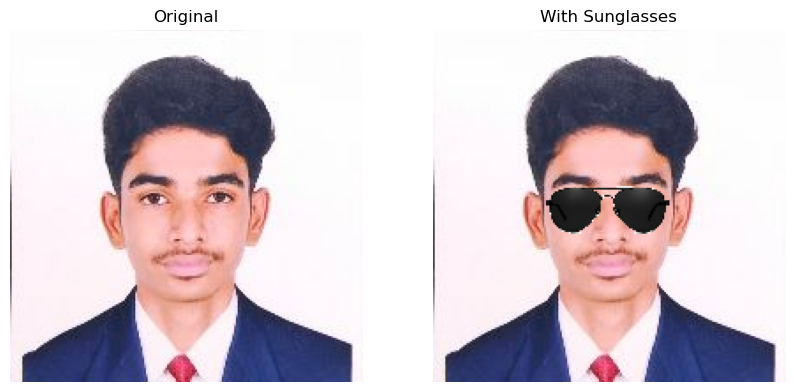

In [41]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(cv2.imread("C:\\Users\\admin\\Downloads\\my photo.jpg"), cv2.COLOR_BGR2RGB))
print("SANTHOSH KUMAR A")
print("212224230250")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
plt.title("With Sunglasses")
plt.axis("off")

plt.show()